In [1]:
import pandas as pd

In [7]:
import pandas as pd

df_examples = pd.read_parquet(
    "../data/raw/shopping_queries_dataset_examples.parquet"
)

df_products = pd.read_parquet(
    "../data/raw/shopping_queries_dataset_products.parquet"
)

df_sources = pd.read_csv(
    "../data/raw/shopping_queries_dataset_sources.csv"
)

In [ ]:
print("Examples s hape :", df_examples.shape)
print("Products shape :", df_products.shape)
print("Sources shape  :", df_sources.shape)

Examples shape : (2621288, 9)
Products shape : (1814924, 7)
Sources shape  : (130652, 2)


In [9]:
print("Examples columns:")
print(df_examples.columns.tolist())

print("\nProducts columns:")
print(df_products.columns.tolist())

print("\nSources columns:")
print(df_sources.columns.tolist())

Examples columns:
['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split']

Products columns:
['product_id', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_locale']

Sources columns:
['query_id', 'source']


In [10]:
print(df_examples["esci_label"].value_counts())

esci_label
E    1708158
S     574313
I     263165
C      75652
Name: count, dtype: int64


In [11]:
print(df_examples["esci_label"].value_counts(normalize=True) * 100)

esci_label
E    65.164835
S    21.909573
I    10.039530
C     2.886062
Name: proportion, dtype: float64


In [12]:
print(df_examples["product_locale"].value_counts())

product_locale
us    1818825
jp     446053
es     356410
Name: count, dtype: int64


In [13]:
print(df_examples["split"].value_counts())

split
train    1983272
test      638016
Name: count, dtype: int64


In [14]:
print("Unique queries :", df_examples["query_id"].nunique())
print("Unique products:", df_examples["product_id"].nunique())

Unique queries : 130652
Unique products: 1802772


In [15]:
print("Unique product IDs in product table:",
      df_products["product_id"].nunique())

Unique product IDs in product table: 1802772


In [16]:
print(df_examples["esci_label"].value_counts())

print(df_examples["esci_label"].value_counts(normalize=True) * 100)

print(df_examples["product_locale"].value_counts())

print(df_products["product_locale"].value_counts())

print(df_examples["split"].value_counts())

print("Unique queries :", df_examples["query_id"].nunique())
print("Unique products:", df_examples["product_id"].nunique())

esci_label
E    1708158
S     574313
I     263165
C      75652
Name: count, dtype: int64
esci_label
E    65.164835
S    21.909573
I    10.039530
C     2.886062
Name: proportion, dtype: float64
product_locale
us    1818825
jp     446053
es     356410
Name: count, dtype: int64
product_locale
us    1215854
jp     339059
es     260011
Name: count, dtype: int64
split
train    1983272
test      638016
Name: count, dtype: int64
Unique queries : 130652
Unique products: 1802772


In [17]:
query_id = df_examples["query_id"].iloc[0]

df_examples[
    df_examples["query_id"] == query_id
][[
    "query_id",
    "query",
    "product_id",
    "esci_label",
    "product_locale",
    "split"
]]

,query_id,query,product_id,esci_label,product_locale,split
0,0,revent 80 cfm,B000MOO21W,I,us,train
1,0,revent 80 cfm,B07X3Y6B1V,E,us,train
2,0,revent 80 cfm,B07WDM7MQQ,E,us,train
3,0,revent 80 cfm,B07RH6Z8KW,E,us,train
4,0,revent 80 cfm,B07QJ7WYFQ,E,us,train
5,0,revent 80 cfm,B076Q7V5WX,E,us,train
6,0,revent 80 cfm,B075ZBF9HG,E,us,train
7,0,revent 80 cfm,B06W2LB17J,E,us,train
8,0,revent 80 cfm,B07JY1PQNT,E,us,train
9,0,revent 80 cfm,B01MZIK0PI,E,us,train


In [18]:
query_products = df_examples[
    df_examples["query_id"] == query_id
]["product_id"]

df_products[
    df_products["product_id"].isin(query_products)
][[
    "product_id",
    "product_title",
    "product_brand",
    "product_color"
]]

,product_id,product_title,product_brand,product_color
167168,B003O0MNGC,Delta BreezSignature VFB25ACH 80 CFM Exhaust B...,DELTA ELECTRONICS (AMERICAS) LTD.,White
167169,B00MARNO5Y,Aero Pure AP80RVLW Super Quiet 80 CFM Recessed...,Aero Pure,White
167170,B011RX6PNO,Aero Pure AP120H-SL W Slim Fit 120 CFM Bathroo...,Aero Pure,White Finish
167171,B01MZIK0PI,Delta Electronics (Americas) Ltd. RAD80 Delta ...,DELTA ELECTRONICS (AMERICAS) LTD.,With Heater
167172,B01N5Y6002,Delta Electronics (Americas) Ltd. GBR80HLED De...,DELTA ELECTRONICS (AMERICAS) LTD.,"With LED Light, Dual Speed & Humidity Sensor"
167173,B07JY1PQNT,Aero Pure ABF80 L5 W ABF80L5 Ceiling Mount 80 ...,Aero Pure,White
167174,B07QJ7WYFQ,Panasonic FV-08VRE2 Ventilation Fan with Reces...,Panasonic,White
167175,B07RH6Z8KW,Delta Electronics RAD80L BreezRadiance 80 CFM ...,DELTA ELECTRONICS (AMERICAS) LTD.,White
167176,B07WDM7MQQ,Homewerks 7140-80 Bathroom Fan Ceiling Mount E...,Homewerks,White
229676,B07X3Y6B1V,Homewerks 7141-80 Bathroom Fan Integrated LED ...,Homewerks,80 CFM


In [19]:
print("Total rows:", len(query_df))
print("Unique queries:", query_df["query"].nunique())
print("Unique product IDs:", query_df["product_id"].nunique())

NameError: name 'query_df' is not defined

In [20]:
print("Total rows         :", df_examples.shape[0])
print("Unique queries     :", df_examples["query"].nunique())
print("Unique product IDs :", df_examples["product_id"].nunique())

Total rows         : 2621288
Unique queries     : 130193
Unique product IDs : 1802772


In [21]:
label_counts = (
    df_examples
    .groupby(["query_id", "esci_label"])
    .size()
    .unstack(fill_value=0)
)

print(label_counts.head())

esci_label  C   E   I   S
query_id                 
0           0  14   2   0
1           1   7   5   3
2           1  10  23   4
3           0  21   5  13
4           0  34   0   6


In [22]:
avg_counts = (
    df_examples
    .groupby(["query_id", "esci_label"])
    .size()
    .unstack(fill_value=0)
    .mean()
)

print("Average E:", avg_counts.get("E", 0))
print("Average S:", avg_counts.get("S", 0))
print("Average I:", avg_counts.get("I", 0))
print("Average C:", avg_counts.get("C", 0))

Average E: 13.074105256712489
Average S: 4.395745951076141
Average I: 2.0142439457490124
Average C: 0.5790343814101583


In [23]:
avg_counts = label_counts.mean()

print(avg_counts)

esci_label
C     0.579034
E    13.074105
I     2.014244
S     4.395746
dtype: float64


In [24]:
df_examples.isnull().sum()

example_id        0
query             0
query_id          0
product_id        0
product_locale    0
esci_label        0
small_version     0
large_version     0
split             0
dtype: int64

In [25]:
es_counts = df_examples["esci_label"].value_counts()

total = len(df_examples)

print("E count      :", es_counts.get("E", 0))
print("E percentage :", es_counts.get("E", 0) / total * 100)

print("S count      :", es_counts.get("S", 0))
print("S percentage :", es_counts.get("S", 0) / total * 100)

E count      : 1708158
E percentage : 65.16483499714644
S count      : 574313
S percentage : 21.909572698612283


<Axes: title={'center': 'Distribution of Exact (E) vs Substitute (S)'}, xlabel='ESCI Label', ylabel='Number of rows'>

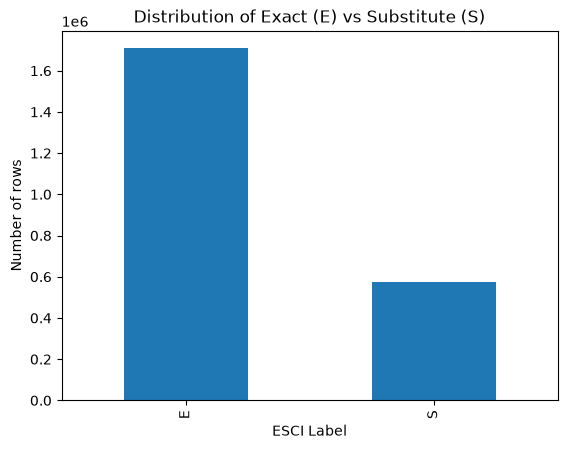

In [26]:
es_counts = df_examples["esci_label"].value_counts()

es_counts[["E", "S"]].plot(
    kind="bar",
    title="Distribution of Exact (E) vs Substitute (S)",
    xlabel="ESCI Label",
    ylabel="Number of rows"
)

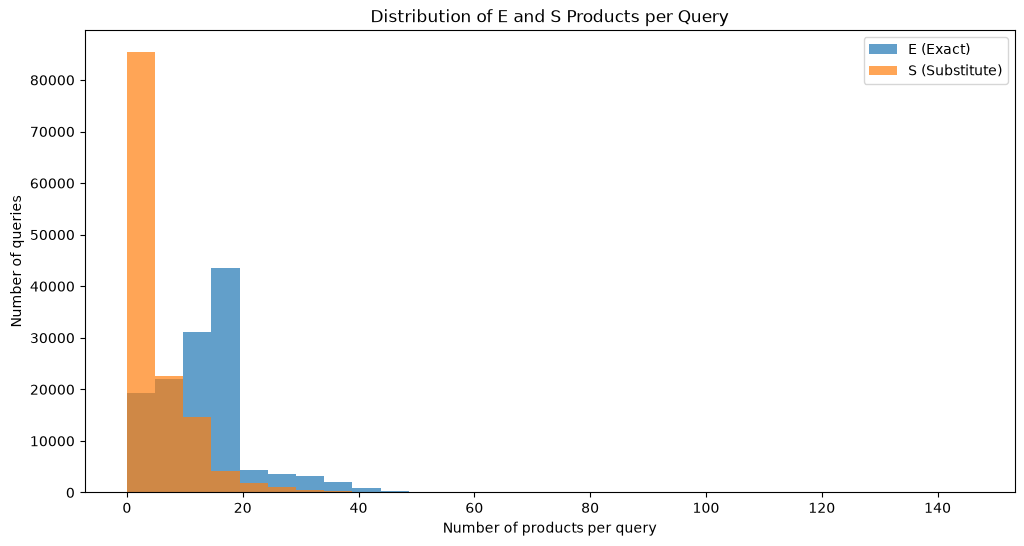

In [27]:
import matplotlib.pyplot as plt

# Count E and S for each query
es_distribution = (
    df_examples[df_examples["esci_label"].isin(["E", "S"])]
    .groupby(["query_id", "esci_label"])
    .size()
    .unstack(fill_value=0)
)

# Plot E and S together
es_distribution[["E", "S"]].plot(
    kind="hist",
    bins=30,
    alpha=0.7,
    figsize=(12, 6)
)

plt.xlabel("Number of products per query")
plt.ylabel("Number of queries")
plt.title("Distribution of E and S Products per Query")
plt.legend(["E (Exact)", "S (Substitute)"])
plt.show()

In [28]:
print("Example product IDs:")
print(df_examples["product_id"].head(10).tolist())

print("\nProduct table IDs:")
print(df_products["product_id"].head(10).tolist())

Example product IDs:
['B000MOO21W', 'B07X3Y6B1V', 'B07WDM7MQQ', 'B07RH6Z8KW', 'B07QJ7WYFQ', 'B076Q7V5WX', 'B075ZBF9HG', 'B06W2LB17J', 'B07JY1PQNT', 'B01MZIK0PI']

Product table IDs:
['B079VKKJN7', 'B079Y9VRKS', 'B07DP4LM9H', 'B07G37B9HP', 'B07LCTGDHY', 'B07MSD1JH3', 'B07QKLGMHM', 'B07S1VM815', 'B07T1HCDXG', 'B07VCV1LSQ']


In [29]:
matched = df_examples["product_id"].isin(df_products["product_id"])

print("Matched:", matched.sum())
print("Unmatched:", (~matched).sum())
print("Match %:", matched.mean() * 100)

Matched: 2621288
Unmatched: 0
Match %: 100.0


In [30]:
df_merged = df_examples.merge(
    df_products,
    on="product_id",
    how="left"
)

print(df_merged.shape)
display(df_merged.head())

(2680364, 15)


,example_id,query,query_id,product_id,product_locale_x,esci_label,small_version,large_version,split,product_title,product_description,product_bullet_point,product_brand,product_color,product_locale_y
0,0,revent 80 cfm,0,B000MOO21W,us,I,0,1,train,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceil...,NaN,WhisperCeiling fans feature a totally enclosed...,Panasonic,White,us
1,1,revent 80 cfm,0,B07X3Y6B1V,us,E,0,1,train,Homewerks 7141-80 Bathroom Fan Integrated LED ...,NaN,OUTSTANDING PERFORMANCE: This Homewerk's bath ...,Homewerks,80 CFM,us
2,2,revent 80 cfm,0,B07WDM7MQQ,us,E,0,1,train,Homewerks 7140-80 Bathroom Fan Ceiling Mount E...,NaN,OUTSTANDING PERFORMANCE: This Homewerk's bath ...,Homewerks,White,us
3,3,revent 80 cfm,0,B07RH6Z8KW,us,E,0,1,train,Delta Electronics RAD80L BreezRadiance 80 CFM ...,This pre-owned or refurbished product has been...,Quiet operation at 1.5 sones\nBuilt-in thermos...,DELTA ELECTRONICS (AMERICAS) LTD.,White,us
4,4,revent 80 cfm,0,B07QJ7WYFQ,us,E,0,1,train,Panasonic FV-08VRE2 Ventilation Fan with Reces...,NaN,The design solution for Fan/light combinations...,Panasonic,White,us


In [31]:
(df_merged["product_locale_x"] == df_merged["product_locale_y"]).value_counts()

True     2621288
False      59076
Name: count, dtype: int64

In [32]:
df_merged.loc[
    df_merged["product_locale_x"] != df_merged["product_locale_y"],
    ["product_locale_x", "product_locale_y"]
].value_counts()

product_locale_x  product_locale_y
us                es                  23295
es                us                  12590
us                jp                  12486
jp                us                   5977
es                jp                   2576
jp                es                   2152
Name: count, dtype: int64

In [33]:
print("Examples rows :", df_examples.shape[0])
print("Products rows :", df_products.shape[0])
print("Merged rows   :", df_merged.shape[0])

Examples rows : 2621288
Products rows : 1814924
Merged rows   : 2680364


In [34]:
print(
    "Duplicate product IDs:",
    df_products["product_id"].duplicated().sum()
)

Duplicate product IDs: 12152


In [35]:
print(
    df_products.groupby("product_id")["product_locale"]
    .nunique()
    .value_counts()
)

product_locale
1    1791205
2      10982
3        585
Name: count, dtype: int64


In [37]:
print("Missing product title :", df_merged["product_title"].isna().sum())
print("Missing brand         :", df_merged["product_brand"].isna().sum())
print("Missing color         :", df_merged["product_color"].isna().sum())

Missing product title : 0
Missing brand         : 167402
Missing color         : 928723


In [38]:
print(
    df_products.duplicated(
        subset=["product_id", "product_locale"]
    ).sum()
)

0


In [39]:
example_ids = set(df_examples["product_id"])
product_ids = set(df_products["product_id"])

not_in_products = example_ids - product_ids

print("Product IDs in examples but NOT in products:",
      len(not_in_products))

Product IDs in examples but NOT in products: 0


In [40]:
not_in_examples = product_ids - example_ids

print("Product IDs in products but NOT in examples:",
      len(not_in_examples))

Product IDs in products but NOT in examples: 0


In [41]:
example_keys = set(
    zip(df_examples["product_id"], df_examples["product_locale"])
)

product_keys = set(
    zip(df_products["product_id"], df_products["product_locale"])
)

not_mapped = example_keys - product_keys

print("Unmapped example product-locale pairs:", len(not_mapped))

Unmapped example product-locale pairs: 0


In [42]:
duplicates = df_products.duplicated(
    subset=["product_id", "product_locale"]
).sum()

print("Duplicate product_id + locale:", duplicates)

Duplicate product_id + locale: 0


In [43]:
print(df_sources.shape)
print(df_sources["source"].value_counts())
print(df_sources["query_id"].nunique())
print(df_sources.isnull().sum())

(130652, 2)
source
other            113656
negations          6964
parse_pattern      6083
behavioral         3780
nlqec               169
Name: count, dtype: int64
130652
query_id    0
source      0
dtype: int64


In [50]:
print("Unique query IDs in examples:", df_examples["query_id"].nunique())
print("Unique query IDs in sources:", df_sources["query_id"].nunique())

print(
    "Duplicate query IDs in sources:",
    df_sources["query_id"].duplicated().sum()
)

print(
    "Duplicate query IDs in sources:",
    df_examples["query_id"].duplicated().sum()
)

Unique query IDs in examples: 130652
Unique query IDs in sources: 130652
Duplicate query IDs in sources: 0
Duplicate query IDs in sources: 2490636


In [45]:
df_examples_with_source = df_examples.merge(
    df_sources,
    on="query_id",
    how="left",
    validate="many_to_one"
)

In [46]:
print("Before merge:", len(df_examples))
print("After merge :", len(df_examples_with_source))

Before merge: 2621288
After merge : 2621288


In [47]:
df_merged = df_examples.merge(
    df_products,
    on=["product_id", "product_locale"],
    how="left",
    validate="many_to_one"
)

In [48]:
print("Examples rows:", len(df_examples))
print("Merged rows:", len(df_merged))

Examples rows: 2621288
Merged rows: 2621288


In [51]:
df_final = df_merged.merge(
    df_sources,
    on="query_id",
    how="left",
    validate="many_to_one"
)


In [52]:
print("Before:", len(df_merged))
print("After :", len(df_final))
print("Missing source:", df_final["source"].isna().sum())

Before: 2621288
After : 2621288
Missing source: 0


In [53]:
print(df_final.columns.tolist())

['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'source']


In [54]:
print("Shape:", df_final.shape)

Shape: (2621288, 15)


In [55]:
print(
    "Duplicate query-product pairs:",
    df_final.duplicated(
        subset=["query_id", "product_id", "product_locale"]
    ).sum()
)

Duplicate query-product pairs: 0


In [56]:
missing = df_final.isnull().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

product_description     1348674
product_color            910895
product_bullet_point     364761
product_brand            166854
dtype: int64


In [57]:
missing = df_final.isnull().sum()

missing_info = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": (missing / len(df_final) * 100).round(2)
})

print(missing_info[missing_info["missing_count"] > 0]
      .sort_values("missing_percentage", ascending=False))

                      missing_count  missing_percentage
product_description         1348674               51.45
product_color                910895               34.75
product_bullet_point         364761               13.92
product_brand                166854                6.37


In [58]:
missing = df_final.isnull().sum()

missing_info = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": (missing / len(df_final) * 100).round(2)
})

print(missing_info[missing_info["missing_count"] > 0]
      .sort_values("missing_percentage", ascending=False))

                      missing_count  missing_percentage
product_description         1348674               51.45
product_color                910895               34.75
product_bullet_point         364761               13.92
product_brand                166854                6.37


In [59]:
print(df_final["esci_label"].value_counts())

esci_label
E    1708158
S     574313
I     263165
C      75652
Name: count, dtype: int64


In [60]:
print(
    df_final["esci_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

esci_label
E    65.16
S    21.91
I    10.04
C     2.89
Name: proportion, dtype: float64


In [61]:
print(df_final["split"].value_counts())

split
train    1983272
test      638016
Name: count, dtype: int64


In [62]:
print(
    pd.crosstab(
        df_final["split"],
        df_final["esci_label"]
    )
)

esci_label      C        E       I       S
split                                     
test        20856   393363   70440  153357
train       54796  1314795  192725  420956


In [63]:
print(
    df_final.groupby("split")["query_id"].nunique()
)

split
test     30969
train    99684
Name: query_id, dtype: int64


In [64]:
duplicate_pairs = df_final.duplicated(
    subset=["query_id", "product_id", "product_locale"]
)

print("Duplicate query-product rows:", duplicate_pairs.sum())

Duplicate query-product rows: 0


In [65]:
train_df = df_final[df_final["split"] == "train"].copy()
test_df = df_final[df_final["split"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (1983272, 15)
Test shape : (638016, 15)


In [66]:
print("Train queries:", train_df["query_id"].nunique())
print("Test queries :", test_df["query_id"].nunique())

Train queries: 99684
Test queries : 30969


In [67]:
df_E = train_df[train_df["esci_label"] == "E"]
df_S = train_df[train_df["esci_label"] == "S"]
df_C = train_df[train_df["esci_label"] == "C"]
df_I = train_df[train_df["esci_label"] == "I"]

print("E:", len(df_E))
print("S:", len(df_S))
print("C:", len(df_C))
print("I:", len(df_I))

E: 1314795
S: 420956
C: 54796
I: 192725


In [68]:
train_df[
    [
        "query",
        "product_id",
        "product_title",
        "product_brand",
        "product_color",
        "product_bullet_point",
        "product_description",
        "esci_label"
    ]
].sample(10, random_state=42)

,query,product_id,product_title,product_brand,product_color,product_bullet_point,product_description,esci_label
1814033,shit i cant remenber,1093564644,"Shit I Can't Remember: Organizer, Log Book & N...",Independently Published,NaN,NaN,NaN,E
1298780,maritini glasses,B082447JXK,LAV Martini Glasses Set of 6 - Martini Cocktai...,lav,Clear,CLASSIC CHIC DESIGN - LAV martini glasses set ...,NaN,E
148816,acesorios barco,B00QC00X68,"Velleman - Juego de 2 altavoces cónicos 5"" con...",Velleman,NaN,"Completamente resistentes al agua, diseñados p...",NaN,E
2510108,委員長さっきトイレでオナってたでしょイッた回数がバレちゃう世界,B08WXDBM7S,【フルカラー】委員長、さっきトイレでオナってたでしょ？～イッた回数がバレちゃう世界～【合本版...,NaN,NaN,NaN,「なんで…バレて…んっっ」敏感過ぎるアソコへの尋問にヒクヒクと悶絶する委員長。イキそうだけど...,E
1815282,shoe risers,B01K64BCWE,CALTO Height Increase Half Elevator Insole for...,CALTO,Black,✔ELEVATOR SHOE EFFECT - Inserts provides subtl...,Each order is pack of two pairs. 1/2 inch heig...,E
2575921,綾鷹ラベルなし,B06X6LV73Y,【まとめ買い】コカ・コーラ 綾鷹（あやたか） 緑茶 525ml×24本（1ケース） ペットボ...,ノーブランド品,NaN,【出荷目安】：2 - 7営業日 ※土日・祝除く 【同梱区分】：TS 1568 【梱包サイズ】...,【出荷目安】：2 - 7営業日 ※土日・祝除く 【同梱区分】：TS 1568 【梱包サイズ】...,S
1235366,lineaaqua steam shower generator,B082J56HPD,SteamSpa Executive 9 KW QuickStart Acu-Steam B...,Steam Spa,Brushed Nickel,[ STEAMSPA ] : SteamSpa is continuously refini...,The perfect steam sauna experience is exactly ...,S
1597637,pleased but not satisfied,149266247X,How to Catch a Mermaid,Sourcebooks Wonderland,NaN,NaN,NaN,I
244390,auto starter remote start system,B07ZKXDVD3,MPC 4-Button Remote Start and Keyless Entry fo...,MPC,Gas - Key-to-Start,✅ WHAT YOU NEED TO KNOW - This is a complete r...,This package is a complete prewired remote sta...,E
1785122,screen protector for iphone 8 plus privacy,B01LYH5N7G,ZAGG InvisibleShield Glass+ Privacy Screen Pro...,ZAGG,Transparent,FULL-SCREEN PRIVACY – Keep prying eyes from lo...,NaN,E


In [69]:
train_df.groupby("esci_label")["query_id"].nunique()

esci_label
C    16745
E    99684
I    36649
S    60945
Name: query_id, dtype: int64

In [70]:
train_df.groupby("esci_label")["product_id"].nunique()

esci_label
C      51774
E    1025592
I     166753
S     356224
Name: product_id, dtype: int64

In [71]:
query_id = train_df["query_id"].value_counts().index[0]

train_df[
    train_df["query_id"] == query_id
][
    [
        "query_id",
        "query",
        "product_id",
        "product_title",
        "esci_label"
    ]
]

,query_id,query,product_id,product_title,esci_label
2066706,105870,tv,B07V4TC9V8,"TCL 65"" Class 6-Series 4K UHD QLED Dolby Visio...",E
2066707,105870,tv,B07V5WY147,"TCL 55"" Class 6-Series 4K UHD QLED Dolby Visio...",E
2066708,105870,tv,B07V6P4H1Z,WeGuard UpBrigh 19V AC/DC Adapter Replacement ...,C
2066709,105870,tv,B07VVMGJYT,PDi Swivel Stem Cover for The Persona P15X Arm...,I
2066710,105870,tv,B07W1121LW,"VIZIO 24 Inch Smart TV, D-Series Television Fu...",E
...,...,...,...,...,...
2066899,105870,tv,B07CL4GLQW,SAMSUNG 32-inch Class LED Smart FHD TV 1080P (...,E
2066900,105870,tv,B07BRD6KBH,The Flash TV Series Season 4 Logo T Shirt & St...,I
2066901,105870,tv,B07BRBVF1R,The Flash TV Series Reverse Flash Logo T Shirt...,I
2066902,105870,tv,B07886XNK8,Unofficial Samsung SmartTV Controller,E
